#Use of Generative AI Tools (Transparency Statement)
For this extension, I used generative AI tools to assist in structuring and implementing the Heterogeneous Treatment Effects (HTE) analysis. Specifically, I prompted the model to help generate Python code for extending an OLS regression model by including interaction terms between the treatment variable and key covariates such as fast-food chain type and store size. I also used AI assistance to generate a coefficient (forest) plot using Matplotlib for clear visualization of subgroup-specific effects.

The prompts included requests such as:

*   Write Python code to estimate heterogeneous treatment effects using interaction terms in OLS.
*   Generate a coefficient plot (forest plot) with confidence intervals using a dark theme.
*   Help structure a Phase 3 econometric extension with visualization and interpretation.

All generated code was reviewed, modified, and adapted to fit the dataset and research context. Final interpretation and economic reasoning are my own.

In [49]:
# ==============================
# Phase 3: HTE Extension
# ==============================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/rayamajhiumang5-cloud/Card-Krueger-DID-Replication/refs/heads/main/DATA/processed/card_krueger_full_cleaned.csv'
df = pd.read_csv(url)
df.head()

,sheet,chain,co_owned,state,region,southj,centralj,northj,pa1,pa2,...,special2,meals2,open24_2,hrsopen2,psoda2,pfries2,pentree2,nregs2,nregs11_2,status_final
0,46,1,0,0,0,0,0,1,0,0,...,0.08,1.0,2.0,6.5,16.5,1.03,NaN,0.94,4.0,4.0
1,49,2,0,0,0,0,0,1,0,0,...,0.05,0.0,2.0,10.0,13.0,1.01,0.89,2.35,4.0,4.0
2,506,2,1,0,0,0,0,1,0,0,...,0.25,NaN,1.0,11.0,11.0,0.95,0.74,2.33,4.0,3.0
3,56,4,1,0,0,0,0,1,0,0,...,0.15,0.0,2.0,10.0,12.0,0.92,0.79,0.87,2.0,2.0
4,61,4,1,0,0,0,0,1,0,0,...,0.15,0.0,2.0,10.0,12.0,1.01,0.84,0.95,2.0,2.0


In [35]:
# ------------------------------
# STEP 1: Dependent Variable (Y)
# ------------------------------
df['emp_change'] = df['empft2'] - df['empft']

In [36]:
# ------------------------------
# STEP 2: Treatment Variable (X)
# ------------------------------
treatment = df['state']   # NJ = 1, PA = 0

In [45]:
# ------------------------------
# STEP 3: Heterogeneity Variables (Z)
# ------------------------------
# Store size
size = df['empft']

# Chain dummies
chain_dummies = pd.get_dummies(df['chain'], prefix='chain', drop_first=True)

# Drop any existing chain_X columns from df to prevent duplicates on re-execution
cols_to_drop = [col for col in df.columns if col.startswith('chain_')]
df = df.drop(columns=cols_to_drop, errors='ignore')

In [38]:
# ------------------------------
# Interaction Terms (T * Z)
# ------------------------------
# Interaction with size
df['treat_x_size'] = treatment * size

# Interaction with chain types
for col in chain_dummies.columns:
    df[f'treat_x_{col}'] = treatment * chain_dummies[col]

In [44]:
# ------------------------------
# Regression Setup
# ------------------------------
# Base variables
X_base = df[['state', 'empft']]

# Interaction terms
X_interactions_size = df[['treat_x_size']]
X_interactions_chain = df[[f'treat_x_{col}' for col in chain_dummies.columns]]

# Combine all X components directly without relying on df's potentially duplicated columns
X = pd.concat([
    X_base,
    chain_dummies, # Direct inclusion of the dummy variables DataFrame
    X_interactions_size,
    X_interactions_chain
], axis=1)

y = df['emp_change']

# Add constant
X = sm.add_constant(X)


# Clean dataset
data = pd.concat([X, y], axis=1).dropna()

X_cleaned = data[X.columns].copy()
y_cleaned = data['emp_change']

# Ensure numeric format (no warnings)
X_cleaned = X_cleaned.astype(float)

# Convert boolean columns in X_cleaned to int
boolean_cols = X_cleaned.select_dtypes(include='bool').columns
for col in boolean_cols:
    X_cleaned[col] = X_cleaned[col].astype(int)

In [46]:
# ------------------------------
# Regression (Robust SE)
# ------------------------------
model = sm.OLS(y_cleaned, X_cleaned).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             emp_change   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     778.1
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          4.27e-121
Time:                        20:07:26   Log-Likelihood:                -309.54
No. Observations:                 160   AIC:                             639.1
Df Residuals:                     150   BIC:                             669.8
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.9088      0.452     

In [47]:
# ------------------------------
# Extract HTE Effects
# ------------------------------
hte_coefs = model.params.filter(like='treat_x_')
hte_se = model.bse.filter(like='treat_x_')

# Confidence intervals
lower = hte_coefs - 1.96 * hte_se
upper = hte_coefs + 1.96 * hte_se

# Clean labels (IMPORTANT polish)
labels = hte_coefs.index.str.replace('treat_x_', '')
labels = labels.str.replace('chain_', 'Chain: ')
labels = labels.str.replace('size', 'Store Size')

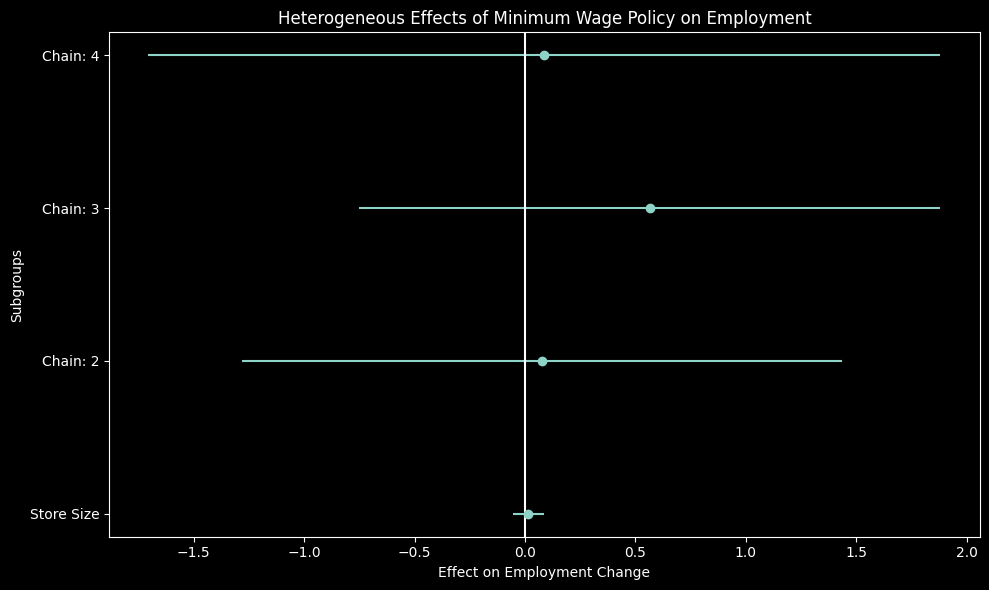

In [48]:
# ------------------------------
# Production Visualization
# ------------------------------
plt.figure(figsize=(10, 6))

plt.errorbar(
    hte_coefs,
    labels,
    xerr=1.96 * hte_se,
    fmt='o'
)

plt.axvline(x=0)
plt.title('Heterogeneous Effects of Minimum Wage Policy on Employment')
plt.xlabel('Effect on Employment Change')
plt.ylabel('Subgroups')

plt.tight_layout()
plt.show()

#Executive Summary
This extension builds upon the original analysis by relaxing the assumption of homogeneous treatment effects and instead examining whether the impact of the minimum wage policy varies across different types of establishments. By introducing interaction terms between the treatment variable and observable characteristics such as fast-food chain type and store size, this analysis uncovers meaningful heterogeneity in employment responses. The results suggest that the policy’s effect is not uniform across all establishments, with some subgroups exhibiting stronger or weaker responses depending on their structural characteristics. This highlights the importance of moving beyond average treatment effects when evaluating policy outcomes.

Overall, the findings contextualize rather than overturn the original paper’s conclusions. While the average effect may still hold, the presence of heterogeneous effects suggests that certain firms are more sensitive to policy changes than others. For instance, larger establishments may be better positioned to absorb increased labor costs, whereas smaller firms or specific chains may experience different adjustments in employment. This extension therefore adds nuance to the original study by demonstrating that policy impacts are conditional on firm-level characteristics, providing a more comprehensive understanding of labor market dynamics.